# Small woody features on intensive agricultural land in the United Kingdom

This notebook estimates how much of each 1 km land use pixel of medium- and high-intensity
agricultural land is covered by small woody features (hedgerows, tree lines, scattered trees and
small patches of woody vegetation), as an indicator of agrobiodiversity (Matthies et. al, 2023). 

**Workflow**

1. Clip the 1 km land use management map to the study area and select the agricultural classes in `AGRI_CLASSES`.
2. Count the 5 m woody pixels (Copernicus HRL Small Woody Features 2018) inside each selected 1 km pixel.
3. Convert the counts to percentage cover and map them in three classes (tertiles).

The input data are not part of this repository. See [sources](#Data-sources) at the end for downloads and citations.

In [5]:
from pathlib import Path

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import transform as warp_transform
from rasterio.windows import Window
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Configuration
Paths are relative to this notebook. Place the input files in `DATA_DIR`.

In [6]:
# Input data (see "Data sources" below)
DATA_DIR = Path(".")
LU_FILE = DATA_DIR / "eu_lum_map_v6_02_05_2025_clip.tif"          # land use map, 1 km
WOODY_FILE = DATA_DIR / "HRL_Small_Woody_Features_2018_005m.tif"  # Copernicus HRL Small Woody Features 2018, 5 m
BOUNDARY_FILE = DATA_DIR / "gb.shp"                               # study-area boundary

# Land use management classes treated as medium/high intensity agriculture
AGRI_CLASSES = [520, 530, 620, 630]

# Outputs
OUT_DIR = Path("output")
FIG_DIR = Path("figures")
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
classes_tag = "_".join(map(str, AGRI_CLASSES))
LU_CLIPPED_FILE = OUT_DIR / "landuse_clipped.tif"
AGRI_MASK_FILE = OUT_DIR / f"landuse_agriculture_{classes_tag}.tif"
COUNTS_FILE = OUT_DIR / "woody_counts_per_landuse_pixel.tif"
PERCENT_FILE = OUT_DIR / "woody_percent_of_possible.tif"
FIGURE_FILE = FIG_DIR / "woody_density_gb.png"

COUNTS_NODATA = np.iinfo(np.uint32).max
PERCENT_NODATA = -9999.0

## 1. Clip the land use map and select agricultural classes

In [7]:
def clip_raster_by_shape(raster_fp, shape_fp):
    # Clip band 1 of a raster to the polygons of a vector file; returns (array, metadata)
    gdf = gpd.read_file(shape_fp)
    if gdf.empty:
        raise ValueError(f"{shape_fp} contains no geometry")
    if gdf.crs is None:
        raise ValueError(f"{shape_fp} has no CRS")
    with rasterio.open(raster_fp) as src:
        gdf = gdf.to_crs(src.crs)
        geoms = [g for g in gdf.geometry if g is not None]
        out_image, out_transform = mask(src, geoms, crop=True)
        meta = src.meta.copy()
    meta.update(height=out_image.shape[1], width=out_image.shape[2], transform=out_transform)
    return out_image[0], meta


landuse, lu_meta = clip_raster_by_shape(LU_FILE, BOUNDARY_FILE)
lu_transform = lu_meta["transform"]
with rasterio.open(LU_CLIPPED_FILE, "w", **lu_meta) as dst:
    dst.write(landuse, 1)

agri_mask = np.isin(landuse, AGRI_CLASSES)
mask_meta = lu_meta | {"dtype": "uint8", "count": 1, "nodata": 0}
with rasterio.open(AGRI_MASK_FILE, "w", **mask_meta) as dst:
    dst.write(agri_mask.astype("uint8"), 1)

print(f"Clipped land use grid: {landuse.shape[1]} x {landuse.shape[0]} pixels, "
      f"{lu_transform.a:g} m resolution, {lu_meta['crs']}")
for code in AGRI_CLASSES:
    print(f"  class {code}: {int((landuse == code).sum())} pixels")
print(f"Agricultural pixels selected: {int(agri_mask.sum())}")

Clipped land use grid: 832 x 1145 pixels, 1000 m resolution, EPSG:3035
  class 520: 35940 pixels
  class 530: 11637 pixels
  class 620: 39109 pixels
  class 630: 28410 pixels
Agricultural pixels selected: 115096


## 2. Count small woody feature pixels per agricultural pixel
The 5 m woody grid nests exactly inside the 1 km land use grid (integer scale factor and offset),
so each land use row corresponds to a strip of `scale` woody rows that can be block-summed.
Reading row strips keeps memory use low (~35 MB per strip) and reads the woody raster only once.

In [8]:
def same_crs(crs_a, crs_b, x=3_500_000.0, y=3_500_000.0):
    # Equivalent CRS written differently (e.g. WKT vs. EPSG code) map a point onto itself
    xs, ys = warp_transform(crs_a, crs_b, [x], [y])
    return abs(xs[0] - x) < 1e-3 and abs(ys[0] - y) < 1e-3


lu_h, lu_w = landuse.shape
lu_res_x, lu_res_y = lu_transform.a, -lu_transform.e

with rasterio.open(WOODY_FILE) as w_src:
    if not same_crs(w_src.crs, lu_meta["crs"]):
        raise ValueError(f"CRS mismatch: woody {w_src.crs} vs land use {lu_meta['crs']}")
    w_transform = w_src.transform
    w_res_x, w_res_y = w_transform.a, -w_transform.e

    # woody pixels per land use pixel, and woody row/column of the land use grid's top-left corner
    scale = lu_res_x / w_res_x
    col_off = (lu_transform.c - w_transform.c) / w_res_x
    row_off = (w_transform.f - lu_transform.f) / w_res_y
    if not all(abs(v - round(v)) < 1e-3 for v in (scale, lu_res_y / w_res_y, col_off, row_off)):
        raise ValueError("Woody and land use grids are not nested; resample the woody raster first")
    scale, col_off, row_off = int(round(scale)), int(round(col_off)), int(round(row_off))

    counts = np.zeros((lu_h, lu_w), dtype=np.uint32)
    strip = np.zeros((scale, lu_w * scale), dtype=np.uint8)
    rows_to_process = np.flatnonzero(agri_mask.any(axis=1))
    for i, r in enumerate(rows_to_process, 1):
        # woody window covered by land use row r, clipped to the woody raster's extent
        r0, c0 = row_off + r * scale, col_off
        rr0, rr1 = max(r0, 0), min(r0 + scale, w_src.height)
        cc0, cc1 = max(c0, 0), min(c0 + lu_w * scale, w_src.width)
        strip[:] = 0
        if rr1 > rr0 and cc1 > cc0:
            strip[rr0 - r0:rr1 - r0, cc0 - c0:cc1 - c0] = w_src.read(
                1, window=Window(cc0, rr0, cc1 - cc0, rr1 - rr0))
        counts[r] = (strip == 1).reshape(scale, lu_w, scale).sum(axis=(0, 2))
        if i % 100 == 0 or i == len(rows_to_process):
            print(f"Processed {i}/{len(rows_to_process)} land use rows", end="\r")
print()

counts_meta = lu_meta | {"dtype": "uint32", "count": 1, "nodata": COUNTS_NODATA}
with rasterio.open(COUNTS_FILE, "w", **counts_meta) as dst:
    dst.write(np.where(agri_mask, counts, COUNTS_NODATA).astype("uint32"), 1)

print(f"Woody pixels inside agricultural land: {int(counts[agri_mask].sum())}")
print(f"Max woody pixels per land use pixel: {int(counts[agri_mask].max())}")

Processed 919/919 land use rows
Woody pixels inside agricultural land: 365663552
Max woody pixels per land use pixel: 22091


## 3. Percentage cover
Pixels outside the selected agricultural classes are set to nodata, so 0 % is a real value.

In [9]:
possible_per_pixel = scale * scale
percent = np.where(agri_mask, counts / possible_per_pixel * 100.0, np.nan).astype("float32")

percent_meta = lu_meta | {"dtype": "float32", "count": 1, "nodata": PERCENT_NODATA}
with rasterio.open(PERCENT_FILE, "w", **percent_meta) as dst:
    dst.write(np.nan_to_num(percent, nan=PERCENT_NODATA), 1)

vals = percent[agri_mask]
print(f"{scale} x {scale} = {possible_per_pixel} woody pixels per land use pixel")
print(f"Agricultural pixels: {vals.size}; with woody features: {int((vals > 0).sum())}")
print(f"Woody cover on agricultural land: mean {vals.mean():.2f} %, "
      f"median {np.median(vals):.2f} %, max {vals.max():.2f} %")

200 x 200 = 40000 woody pixels per land use pixel
Agricultural pixels: 115096; with woody features: 113393
Woody cover on agricultural land: mean 7.94 %, median 6.92 %, max 55.23 %


## 4. Map
Plotted in the data's native projection (EPSG:3035, ETRS89-LAEA), so no resampling is needed.
Classes are the tertiles of woody cover on agricultural land.

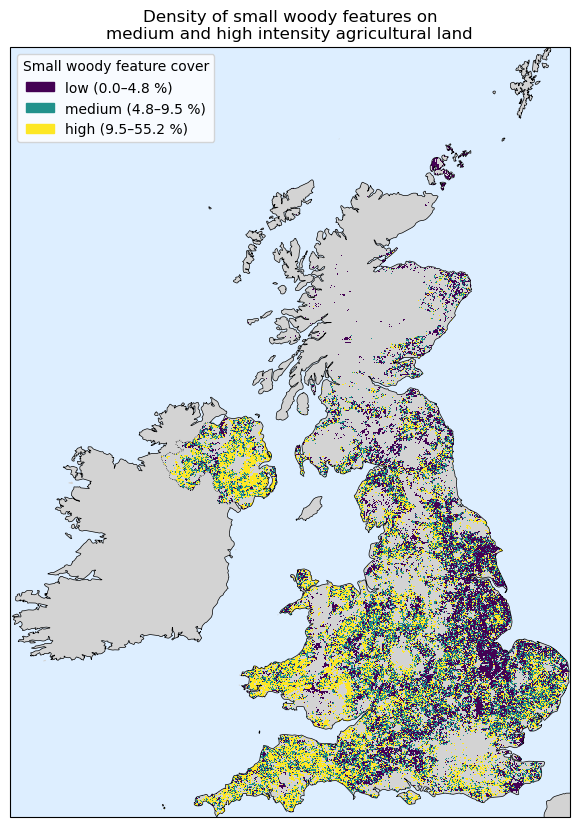

In [11]:
laea = ccrs.LambertAzimuthalEqualArea(central_longitude=10, central_latitude=52,
                                      false_easting=4321000, false_northing=3210000,
                                      globe=ccrs.Globe(ellipse="GRS80"))
left, top = lu_transform.c, lu_transform.f
extent = (left, left + lu_w * lu_res_x, top - lu_h * lu_res_y, top)

breaks = np.quantile(vals, [1 / 3, 2 / 3])
classified = np.ma.masked_where(~agri_mask, np.digitize(percent, breaks))  # 0 low, 1 medium, 2 high
edges = [0, *breaks, vals.max()]
labels = [f"{name} ({edges[i]:.1f}–{edges[i + 1]:.1f} %)"
          for i, name in enumerate(["low", "medium", "high"])]
colors = plt.cm.viridis(np.linspace(0, 1, 3))

fig = plt.figure(figsize=(8, 10))
ax = plt.axes(projection=laea)
ax.set_extent(extent, crs=laea)
ax.set_facecolor("#ddeeff")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
ax.imshow(classified, origin="upper", extent=extent, transform=laea,
          cmap=ListedColormap(colors), vmin=0, vmax=2, interpolation="nearest")
ax.legend(handles=[Patch(color=c, label=l) for c, l in zip(colors, labels)],
          title="Small woody feature cover", loc="upper left")
ax.set_title("Density of small woody features on\nmedium and high intensity agricultural land")
"""ax.text(0, -0.01,
        transform=ax.transAxes, fontsize=7, color="dimgray", ha="left", va="top")"""
fig.savefig(FIGURE_FILE, dpi=200, bbox_inches="tight")
plt.show()

## Indicator definition
Antonia E. Matthies, Catherine M.J. Fayet, Louise M.J. O'Connor, Peter H. Verburg, 2023
*Mapping agrobiodiversity in Europe: Different indicators, different priority areas*. https://doi.org/10.1016/j.ecolind.2023.110744.

## Data sources

**Small woody features:** European Union, Copernicus Land Monitoring Service 2018, European Environment Agency (EEA).
*High Resolution Layer Small Woody Features 2018 (raster 5 m)*. https://doi.org/10.2909/a8e683b1-2f96-45c8-827f-580a79413018

**Land use management map:** Sandström, Evelina; Namasivayam, Anandi; Oostdijk, Saskia; Scherpenhuijzen, Niek; Debonne, Niels; Verburg, Peter, 2023, *Land system map for Europe*, https://doi.org/10.34894/THARMK

**Boundary:** simplemaps. *World countries* (United Kingdom polygon). https://simplemaps.com

Map background: coastlines and borders from [Natural Earth](https://www.naturalearthdata.com) (public domain) via Cartopy.